In [301]:
from typing import Callable
import re
import pandas as pd
import numpy as np
from dateutil.parser import parse
import matplotlib as mpl
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
mpl.style.use('dark_background')

import seaborn as sns

from src import Policy_Value_Net

In [64]:
def get_pattern(args: list[str]):
    pattern_builder = r"\[(?P<timestamp>.*?)\] "
    [*head, tail] = args
    for arg in head:
        pattern_builder += f"{arg}: (?P<{arg}>.*?), "
    pattern_builder += f"{tail}: (?P<{tail}>.*)"
    return re.compile(pattern_builder)

def create_df(results: list[dict], argdict: dict[str, Callable]) -> pd.DataFrame:
    if "timestamp" not in argdict:
        argdict["timestamp"] = lambda t: parse(t, fuzzy=True)
    df = pd.DataFrame(results)
    for key, mapfn in argdict.items():
        df[key] = df[key].map(mapfn)
    return df

def corr(df: pd.DataFrame, f1: str, f2: str) -> float:
    corr = df.corr().loc[f1, f2]
    if pd.isna(corr):
        return .0
    return corr

def autocorr(df: pd.DataFrame, f: str) -> float:
    return corr(df, "timestamp", f)

In [65]:
SMALL_GAME = (6, 6, 4)
MEDIUM_GAME = (8, 8, 5)

small_net = Policy_Value_Net(
    game_kwargs=SMALL_GAME, 
    model_file=f"_zero/models/curr_{SMALL_GAME[0]}_{SMALL_GAME[1]}_{SMALL_GAME[2]}.model",
)

medium_net = Policy_Value_Net(
    game_kwargs=MEDIUM_GAME, 
    model_file=f"_zero/models/curr_{MEDIUM_GAME[0]}_{MEDIUM_GAME[1]}_{MEDIUM_GAME[2]}.model",
)

In [66]:
train_keys = {
    "kl": float,
    "lrMultiplier": float,
    "loss": float,
    "entropy": float,
    "explVarOld": float,
    "explVarNew": float,
}

eval_keys = {
    "numPlayouts": int,
    "win": int,
    "lose": int,
    "tie": int,
    "avgCurrStarted": float,
}

In [67]:
train_pattern = get_pattern(train_keys)
eval_pattern = get_pattern(eval_keys)

train_results, eval_results = [], []
with open("_zero/logs/losses.log", "r") as f:
    for line in f.readlines():
        assert line != "", "Empty line"
        train_match = train_pattern.search(line)
        if train_match is not None:
            train_results += [train_match.groupdict()]
        eval_match = eval_pattern.search(line)
        if eval_match is not None:
            eval_results += [eval_match.groupdict()]

train_df = create_df(train_results, train_keys)
eval_df = create_df(eval_results, eval_keys)

In [68]:
train_df.describe()

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
count,4616,4616.000000,4616.000000,4616.000000,4616.000000,4616.000000,4616.000000
mean,2024-01-02 14:15:17.653135360,0.033251,0.091133,2.018761,1.415272,0.241593,0.262765
min,2023-12-30 17:12:39.558000,0.006370,0.088000,1.213490,0.795080,-0.078000,-0.026000
25%,2024-01-01 12:38:43.244499968,0.022100,0.088000,1.784447,1.219947,0.156000,0.172000
50%,2024-01-02 22:04:41.309999872,0.029345,0.088000,1.949595,1.341050,0.254000,0.278000
75%,2024-01-03 14:30:56.261250048,0.039400,0.088000,2.169120,1.520470,0.328250,0.356000
max,2024-01-04 09:13:07.364000,0.127900,0.667000,5.098120,4.124200,0.585000,0.599000
std,NaN,0.016378,0.026680,0.410814,0.370309,0.120879,0.128231


In [69]:
train_df.corr().style.background_gradient("hot")

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
timestamp,1.000000,-0.225162,-0.228183,-0.414541,-0.345342,0.738466,0.774091
kl,-0.225162,1.000000,0.009866,0.067200,0.046135,-0.195902,-0.202002
lrMultiplier,-0.228183,0.009866,1.000000,0.623914,0.622676,-0.206798,-0.210090
loss,-0.414541,0.067200,0.623914,1.000000,0.950263,-0.496397,-0.493267
entropy,-0.345342,0.046135,0.622676,0.950263,1.000000,-0.350768,-0.349207
explVarOld,0.738466,-0.195902,-0.206798,-0.496397,-0.350768,1.000000,0.995207
explVarNew,0.774091,-0.202002,-0.210090,-0.493267,-0.349207,0.995207,1.000000


In [70]:
eval_df.describe()

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
count,92,92.000000,92.000000,92.000000,92.000000,92.000000
mean,2024-01-02 15:10:03.243652096,1603.260870,3.097826,6.826087,0.076087,0.519565
min,2023-12-30 17:23:42.671000,1000.000000,0.000000,0.000000,0.000000,0.200000
25%,2024-01-01 14:23:03.106249984,1500.000000,1.000000,5.000000,0.000000,0.400000
50%,2024-01-02 22:46:21.413500160,1500.000000,2.500000,7.500000,0.000000,0.500000
75%,2024-01-03 14:52:33.087749888,1500.000000,5.000000,9.000000,0.000000,0.600000
max,2024-01-04 09:23:20.553000,3000.000000,10.000000,10.000000,2.000000,0.900000
std,NaN,409.623544,2.589326,2.646203,0.339155,0.148427


In [71]:
eval_df.corr().style.background_gradient("hot")

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
timestamp,1.000000,0.439664,0.742959,-0.761423,0.268651,0.082365
numPlayouts,0.439664,1.000000,0.296010,-0.327941,0.298774,0.020628
win,0.742959,0.296010,1.000000,-0.991842,0.104051,0.129352
lose,-0.761423,-0.327941,-0.991842,1.000000,-0.229981,-0.119942
tie,0.268651,0.298774,0.104051,-0.229981,1.000000,-0.051727
avgCurrStarted,0.082365,0.020628,0.129352,-0.119942,-0.051727,1.000000


In [72]:
# Fairness of Evaluation

round_fairness_significance = .05
n_evaluation_games = 10

n_total_games = len(eval_df) * n_evaluation_games
mean_total_games = int(round(eval_df['avgCurrStarted'].mean() * n_total_games))
std_total_games = int(round(eval_df['avgCurrStarted'].std() * n_total_games))

round_fairness = eval_df["avgCurrStarted"].mean() - .5
round_fairness_autocorr = autocorr(eval_df, "avgCurrStarted")

round_fairness_doubt = False

print(f"[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.")
print(f"[Info] {n_total_games} games played in total, distributed as: [{mean_total_games} - z * {std_total_games}, {mean_total_games} + z * {std_total_games}]")

if abs(round_fairness) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness > .0:
        print(f"[Warn] The number of plays which the CURRENT player started is above the significance: {round_fairness:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started is above the significance: {-round_fairness:.4f} > {round_fairness_significance}")

if abs(round_fairness_autocorr) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness_autocorr > .0:
        print(f"[Warn] The number of plays which the CURRENT player started tend to increase significantly: {round_fairness_autocorr:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started tend to increase significantly: {-round_fairness_autocorr:.4f} > {round_fairness_significance}")

if round_fairness_doubt:
    print(f"[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.")

[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.
[Info] 920 games played in total, distributed as: [478 - z * 137, 478 + z * 137]
[Warn] The number of plays which the CURRENT player started tend to increase significantly: 0.0824 > 0.05
[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.


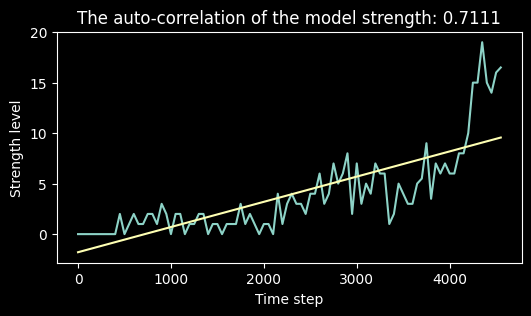

In [73]:
# Difficulty Estimation

eval_checkpoint = 50
num_wins = 10
num_playouts = 1500

eval_df["batch"] = eval_df.index * eval_checkpoint
eval_df.set_index("batch", inplace=True)

eval_df["strength"] = (eval_df["win"] + eval_df["tie"] / 2 + (eval_df["numPlayouts"] / num_playouts  - 1) * num_wins).round(2)
eval_df["strength"] = eval_df["strength"].map(lambda x: 0 if x < 0 else x)

strength_significance = .7

strength_corr = autocorr(eval_df, "strength")
if strength_corr < strength_significance:
    print(f"[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: {strength_corr:.4f} < {strength_significance}")
    print(f"[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn")

x_axis = eval_df.index.values.reshape(-1, 1)

strength_lr = LinearRegression()
strength_lr.fit(x_axis, eval_df["strength"].values)

strength_estimator = lambda x: strength_lr.coef_ * x + strength_lr.intercept_

fig, axes = plt.subplots(1, 1, figsize=(6, 3))

axes = eval_df["strength"].plot(ax=axes)
axes.set_title(f"The auto-correlation of the model strength: {strength_corr:.4f}")
axes.plot(x_axis, list(map(strength_estimator, x_axis)))
axes.set_xlabel('Time step')
axes.set_ylabel('Strength level')

plt.show()

[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training
[Warn] The loss does not decrease significantly, which prevents the convergence of the model: -0.4145 > -0.5
[Warn] There might be a problem in loss function or hyperparameters


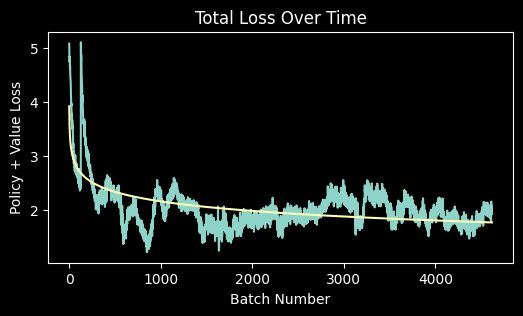

In [74]:
# Loss and Learning Rate

print(f"[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training")

loss_significance = -.5

loss_corr = autocorr(train_df, "loss")

if loss_corr > loss_significance:
    print(f"[Warn] The loss does not decrease significantly, which prevents the convergence of the model: {loss_corr:.4f} > {loss_significance}")
    print(f"[Warn] There might be a problem in loss function or hyperparameters")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1
    
loss_lr = LinearRegression()
loss_lr.fit(np.log(x_axis), train_df["loss"])
loss_estimator = lambda x: loss_lr.coef_[0] * x + loss_lr.intercept_
    
fig, axes = plt.subplots(1, 1, figsize=(6, 3))
ax = train_df["loss"].plot(ax=axes)
ax.set_title("Total Loss Over Time")
ax.set_xlabel("Batch Number")
ax.set_ylabel("Policy + Value Loss")
ax.plot(x_axis, list(map(loss_estimator, np.log(x_axis))))

plt.show()

[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded
[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one
[Warn] Entropy seems to not decrease during training: -0.3453 > -0.5
[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive


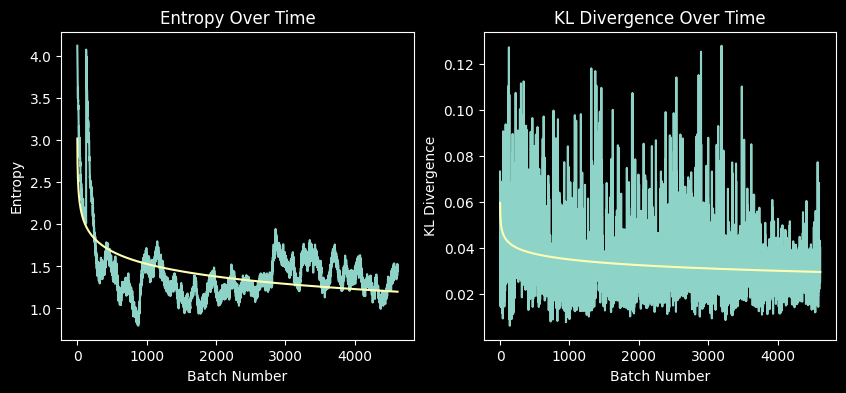

In [75]:
# Measuring Policy Estimation

print(f"[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded")
print(f"[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one")

entropy_significance = -.5
kl_significance = -0.01

entropy_corr = autocorr(train_df, "entropy")
kl_corr = autocorr(train_df, "kl")

if entropy_corr > entropy_significance:
    print(f"[Warn] Entropy seems to not decrease during training: {entropy_corr:.4f} > {entropy_significance}")
    print(f"[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive")

if kl_corr > kl_significance:
    print(f"[Warn] KL Divergence does not decrease over time as much as expected: {kl_corr:.4f} > {kl_significance}")
    print(f"[Warn] The model might still need more training or there might be other destabilizing factors causing this issue")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

entropy_lr = LinearRegression()
entropy_lr.fit(np.log(x_axis), train_df["entropy"].values)
entropy_estimator = lambda x: entropy_lr.coef_[0] * x + entropy_lr.intercept_

kl_lr = LinearRegression()
kl_lr.fit(np.log(x_axis), train_df["kl"])
kl_estimator = lambda x: kl_lr.coef_[0] * x + kl_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1 = train_df["entropy"].plot(ax=axes[0])
ax1.set_title("Entropy Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Entropy")
ax1.plot(x_axis, list(map(entropy_estimator, np.log(x_axis))))

ax2 = train_df["kl"].plot(ax=axes[1])
ax2.set_title("KL Divergence Over Time")
ax2.set_xlabel("Batch Number")
ax2.set_ylabel("KL Divergence")
ax2.plot(x_axis, list(map(kl_estimator, np.log(x_axis))))

plt.show()

[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward


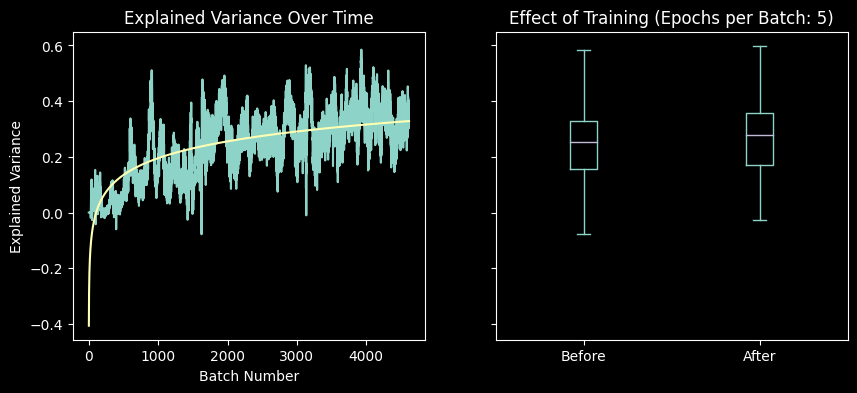

In [76]:
# Measuring Value Estimation

print(f"[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward")

expl_var_significance = .4
expl_var_difference_significance = .01

expl_var_corr = autocorr(train_df, "explVarOld")
if expl_var_corr < expl_var_significance:
    print(f"[Warn] The explained variance seems to not increase over time: {expl_var_corr:.4f} < {expl_var_significance}")
    print(f"[Warn] There might be an unknown learning issue which is probably caused by learning rate, loss function etc.")

expl_var_difference = (train_df["explVarNew"] - train_df["explVarOld"]).mean()
if expl_var_difference < expl_var_difference_significance:
    print(f"[Warn] The new explained variance tends not to differ significantly from the older one: {expl_var_difference:.4f} < {expl_var_difference_significance}")
    print(f"[Warn] Either the value loss is set correctly or the learning rate is too small")

n_epochs = 5

x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

expl_var_lr = LinearRegression()
expl_var_lr.fit(np.log(x_axis), train_df["explVarOld"].values)
expl_var_estimator = lambda x: expl_var_lr.coef_ * x + expl_var_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1 = train_df["explVarOld"].plot(ax=axes[0])
ax1.set_title("Explained Variance Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Explained Variance")
ax1.plot(x_axis, list(map(expl_var_estimator, np.log(x_axis))))

expl_var_difference_stats = train_df[["explVarOld", "explVarNew"]]
ax2 = expl_var_difference_stats.plot(kind="box", ax=axes[1])
ax2.set_title(f"Effect of Training (Epochs per Batch: {n_epochs})")
ax2.set_xticklabels(["Before", "After"])

plt.show()

In [396]:
from tqdm import tqdm
from src import Gomoku, Player, play_game, Rand_Player, Flat_Player, Deep_Player

players = [
    ("Rand", Rand_Player(), .0),
    ("Flat", Flat_Player(policy_value_fn=medium_net.policy_value_fn_sorted), .0),
    ("Zero", Deep_Player(iterations=600, policy_value_fn=medium_net.policy_value_fn_sorted), .0),
    ("MCTS", Deep_Player(iterations=7500), .0),
]

def competition(
    game: Gomoku,
    n_games: int,
    player1_args: tuple[str, Player, float], 
    player2_args: tuple[str, Player, float], 
    fairness: float = .5,
    show_bar: bool = False,
    verbose: bool = False,
) -> pd.DataFrame:
    
    name1, player1, epsilon1 = player1_args
    name2, player2, epsilon2 = player2_args
    
    pbar = range(n_games)
    if show_bar:
        pbar = tqdm(pbar, desc="Competition")
    
    results = []
    for _ in pbar:
        new_game, curr_started = play_game(game, player1, player2, epsilon1, epsilon2, fairness, verbose)
        score = new_game.score()
        if not curr_started:
            score *= -1
        results.append({
            "score": score, 
            "curr_started": curr_started, 
            "length": len(new_game.history),
        })
    
    results = pd.DataFrame(results)    
    
    indices = [f"{name1}_started", f"{name2}_started"] # True, False
    columns = [f"{name1}_won", "Tie", f"{name2}_won"] # 1, 0, -1

    results_counts = pd.DataFrame(index=indices, columns=columns)
    results_lengths = results.copy()

    results_counts.fillna(0, inplace=True)

    for index in indices:
        for column in columns:
            index_val = True if index == f"{name1}_started" else False
            column_val = 1 if column == f"{name1}_won" else -1 if column == f"{name2}_won" else 0
            
            filter_fn = lambda x: (x["curr_started"] == index_val) & (x["score"] == column_val)
            
            results_lengths[index + '_' + column] = results_lengths.apply(lambda x: x["length"] if filter_fn(x) else np.nan, axis=1)
            results_counts.loc[index, column] = len(results[filter_fn(results)]) / n_games
    
    results_lengths.drop(["curr_started", "score", "length"], axis=1, inplace=True)
    
    return results_counts, results_lengths

Competition: 100%|██████████| 10/10 [01:43<00:00, 10.32s/it]
/var/folders/gq/zf4jplr54kzc3vr7btq8ptc40000gp/T/ipykernel_4832/386686982.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  results_counts.loc[index, column] = len(results[filter_fn(results)]) / n_games
/var/folders/gq/zf4jplr54kzc3vr7btq8ptc40000gp/T/ipykernel_4832/192388085.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(results_lengths.columns, rotation=90)


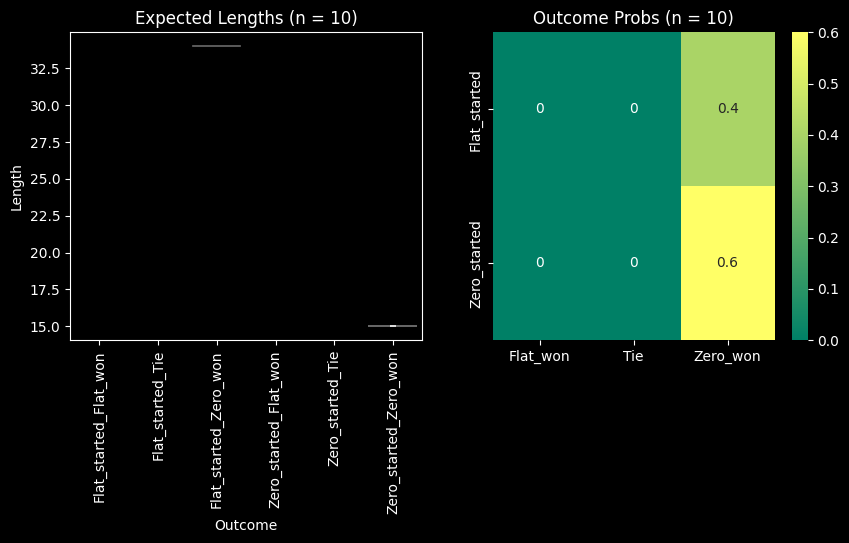

In [397]:
player_i = 1
player_j = 2

game = Gomoku(*MEDIUM_GAME)
n_games = 10

results_counts, results_lengths = competition(
    game, 
    n_games, 
    player1_args=players[player_i],
    player2_args=players[player_j], 
    show_bar=True,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.violinplot(data=results_lengths, ax=axes[0])
    
axes[0].set_title(f"Expected Lengths (n = {n_games})")
axes[0].set_ylabel("Length")
axes[0].set_xlabel("Outcome")
axes[0].set_xticklabels(results_lengths.columns, rotation=90)
    
sns.heatmap(results_counts, cmap="summer", annot=True, ax=axes[1])
axes[1].set_title(f"Outcome Probs (n = {n_games})")

plt.show()

In [385]:
# fst_started_col = f"{players[0][0]}_started"
# snd_started_col = f"{players[1][0]}_started"


# length_results = pd.DataFrame({
#     fst_started_col: results.apply(lambda x: x["length"] if x["curr_started"] else np.nan, axis=1).values,
#     snd_started_col: results.apply(lambda x: x["length"] if not x["curr_started"] else np.nan, axis=1).values,
# })

# length_results.plot(kind="box", title="Length", y=[fst_started_col, snd_started_col], ax=axes[0])

# score_results = pd.DataFrame({
#     fst_started_col: results.apply(lambda x: x["score"] if x["curr_started"] else np.nan, axis=1).values,
#     snd_started_col: results.apply(lambda x: x["score"] if not x["curr_started"] else np.nan, axis=1).values,
# })

# score_results.plot(kind="", title="Score", y=[fst_started_col, snd_started_col], ax=axes[1])

## Game Is Solved For 6, 6, 4!

/var/folders/gq/zf4jplr54kzc3vr7btq8ptc40000gp/T/ipykernel_4832/3496273031.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")


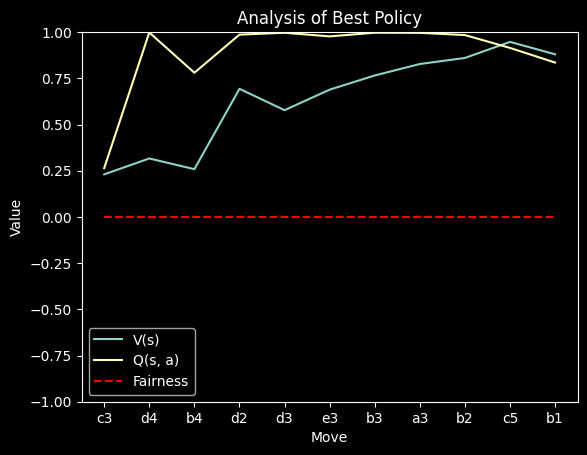

In [61]:
# Fairness of Game

from src import Gomoku, Deep_Player, Pattern

Pi_s = "c3,d4,b4,d2,d3,e3,b3,a3,b2,c5,b1" # winning strategy for the first player

V_s = []
Q_sa = []

net_player = Deep_Player(
    iterations=400, 
    policy_value_fn=small_net.policy_value_fn_sorted, 
    c_puct=5,
)

game = Gomoku(*SMALL_GAME)
for move in Pattern.loc_to_move(Pi_s):
    probs, value = small_net.policy_value_fn_sorted(game)
    max_prob, max_action = max(probs)
    assert max_action == move, "The best policy is different from the given move"
    game.play(move)
    V_s += [value.detach().item()]
    Q_sa += [max_prob]
    
x_axis = Pi_s.split(",")
ax = plt.subplot(1, 1, 1)
ax.plot(x_axis, V_s)
ax.plot(x_axis, Q_sa)
ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")
ax.set_ylim(-1, 1)
ax.set_xlabel("Move")
ax.set_ylabel("Value")
ax.set_title("Analysis of Best Policy")
ax.legend(["V(s)", "Q(s, a)", "Fairness"])
plt.show()